# 🔍 Clustering in Machine Learning — A Beginner's Guide

Welcome! In this notebook you will learn about **clustering**, one of the most popular techniques in **unsupervised machine learning**.

## What you will learn
1. What clustering is and when to use it
2. How the **K-Means** algorithm works step-by-step
3. How to choose the right number of clusters
4. Alternative algorithms: **Hierarchical Clustering** and **DBSCAN**
5. How to evaluate clustering results
6. How to apply clustering to a real-world dataset

## Prerequisites
- Basic Python knowledge (variables, loops, functions)
- No prior machine learning experience required!

---


## 1. What Is Clustering?

**Clustering** means grouping similar data points together *without* any labels telling us which group they belong to. That makes it **unsupervised** — the algorithm discovers structure on its own.

**Real-world examples:**
- Grouping customers by purchasing behavior (marketing)
- Grouping news articles by topic
- Grouping pixels by color to compress an image
- Identifying species of plants by measurements

### Supervised vs. Unsupervised Learning

| | Supervised | Unsupervised |
|---|---|---|
| **Labels** | Has labels (e.g., "cat" / "dog") | No labels |
| **Goal** | Predict a known output | Discover hidden patterns |
| **Example** | Spam detection | Customer segmentation |

---


## 2. Setting Up Our Environment

Let's import the libraries we need. Don't worry if you haven't used all of them before — we'll explain each one as we go.


In [1]:
# Data manipulation
import numpy as np          # numerical computing
import pandas as pd         # data tables (DataFrames)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (scikit-learn)
from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

# Notebook display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


## 3. Creating a Simple Toy Dataset

Before working with real data, let's create a tiny synthetic dataset so we can *see* what clustering does.

The function `make_blobs` generates groups ("blobs") of points for us.


In [2]:
# Create 300 points arranged in 3 natural groups
X_toy, y_true = make_blobs(
    n_samples=300,   # total number of points
    centers=3,       # how many groups to create
    cluster_std=0.8, # how spread out each group is
    random_state=42  # makes results reproducible
)

# X_toy is a 2D array: each row is a point with (x, y) coordinates
print(f"Shape of data: {X_toy.shape}")   # (300, 2)
print(f"First 5 points:\n{X_toy[:5]}")


Shape of data: (300, 2)
First 5 points:
[[-7.24711591 -7.55998509]
 [-7.56795788 -7.18775403]
 [-1.85116169  8.03761121]
 [ 4.46573387  2.85219117]
 [-8.51012682 -7.68657864]]


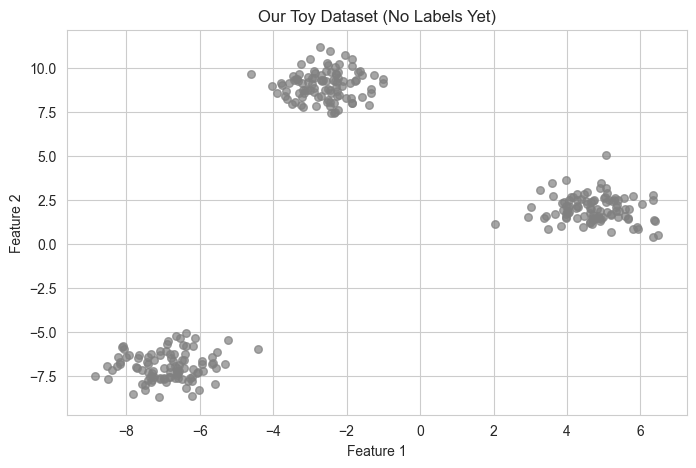

In [3]:
# Let's visualize the raw data (pretending we don't know the groups)
plt.figure(figsize=(8, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], s=30, alpha=0.7, color="gray")
plt.title("Our Toy Dataset (No Labels Yet)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### 📝 TODO #1
Look at the scatter plot above. **How many groups can you see by eye?** Write your answer below.


In [4]:
# TODO #1: Replace the ... with the number of groups you see
my_guess = ... # 3
print(f"I think there are {my_guess} groups in the data.")


I think there are Ellipsis groups in the data.


## 4. K-Means Clustering — Step by Step

K-Means is the most popular clustering algorithm. Here's how it works in plain English:

1. **Pick K** — decide how many clusters you want.
2. **Place centroids** — randomly place K "center" points.
3. **Assign** — each data point joins the nearest centroid's cluster.
4. **Update** — move each centroid to the center (mean) of its cluster.
5. **Repeat** steps 3–4 until the centroids stop moving.

Let's see it in action!


In [5]:
# Run K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,     # K = number of clusters
    random_state=42,  # reproducibility
    n_init=10         # try 10 different starting positions
)

# .fit_predict() runs the algorithm AND returns the cluster label for each point
labels = kmeans.fit_predict(X_toy)

print(f"Cluster labels for first 10 points: {labels[:10]}")
print(f"Unique clusters: {np.unique(labels)}")


Cluster labels for first 10 points: [1 1 0 2 1 2 0 2 0 0]
Unique clusters: [0 1 2]


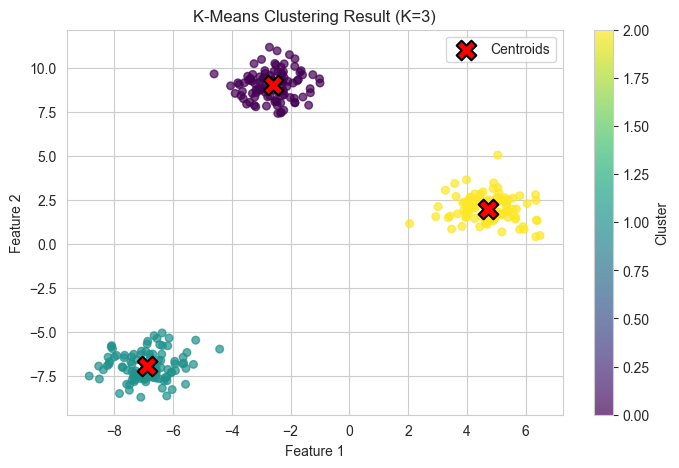

In [6]:
# Visualize the result
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_toy[:, 0], X_toy[:, 1], c=labels, cmap="viridis", s=30, alpha=0.7)

# Mark the centroids with red X's
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c="red", marker="X", s=200, edgecolors="black", linewidths=1.5,
            label="Centroids")

plt.title("K-Means Clustering Result (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()


### 📝 TODO #2
Now try running K-Means with a *wrong* number of clusters (e.g., K=5). What happens?


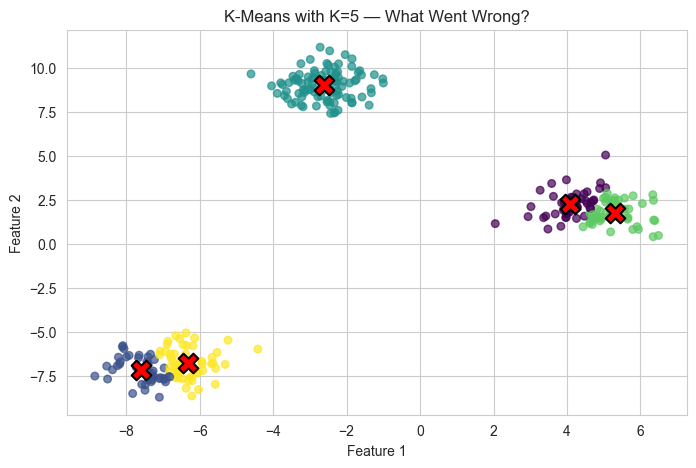

In [ ]:
# TODO #2: Change n_clusters to 5 and observe what happens
kmeans_wrong = KMeans(n_clusters=..., random_state=42, n_init=10)  # replace ... with 5
labels_wrong = kmeans_wrong.fit_predict(X_toy)

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=labels_wrong, cmap="viridis", s=30, alpha=0.7)
centroids_wrong = kmeans_wrong.cluster_centers_
plt.scatter(centroids_wrong[:, 0], centroids_wrong[:, 1],
            c="red", marker="X", s=200, edgecolors="black", linewidths=1.5)
plt.title("K-Means with K=5 — What Went Wrong?")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 5. How to Choose the Right K

Choosing K is one of the biggest challenges. Two popular methods help:

### Method 1: The Elbow Method
- Run K-Means for K = 1, 2, 3, … and record the **inertia** (sum of squared distances from each point to its centroid).
- Plot inertia vs. K — look for an "elbow" where the curve bends.

### Method 2: Silhouette Score
- Measures how similar a point is to its *own* cluster vs. the *nearest other* cluster.
- Ranges from **-1** (bad) to **+1** (great). Higher is better.


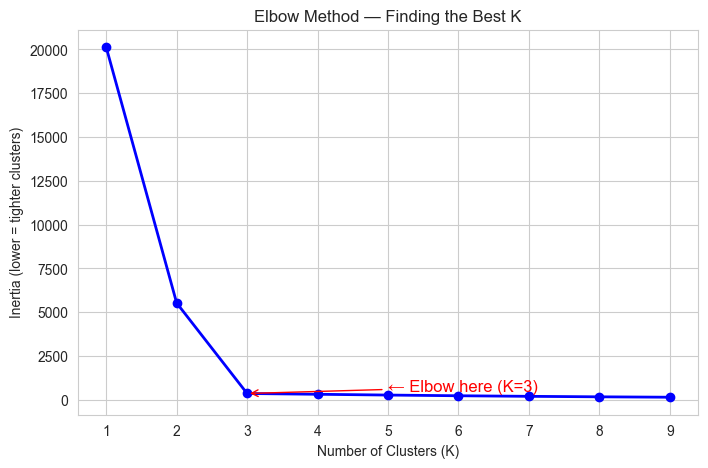

In [8]:
# Elbow Method
inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_toy)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, "bo-", linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (lower = tighter clusters)")
plt.title("Elbow Method — Finding the Best K")
plt.xticks(list(K_range))

# Annotate the elbow
plt.annotate("← Elbow here (K=3)", xy=(3, inertias[2]),
             xytext=(5, inertias[2] + 100),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=12, color="red")
plt.show()


K=2: Silhouette Score = 0.721
K=3: Silhouette Score = 0.878
K=4: Silhouette Score = 0.697
K=5: Silhouette Score = 0.503
K=6: Silhouette Score = 0.327
K=7: Silhouette Score = 0.351
K=8: Silhouette Score = 0.367
K=9: Silhouette Score = 0.369


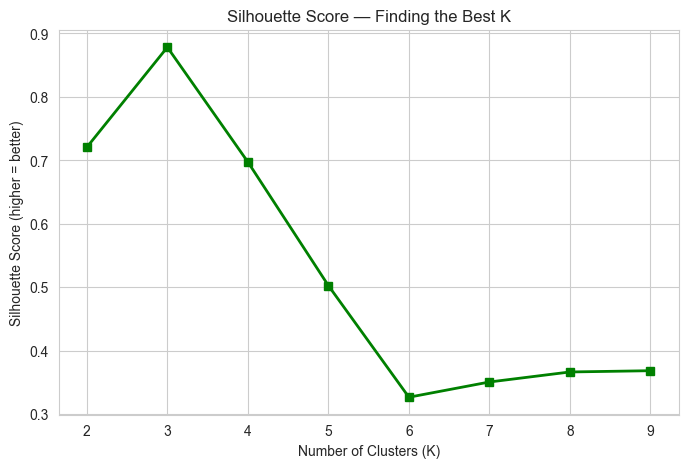

In [9]:
# Silhouette Score for different K values
sil_scores = []
K_range_sil = range(2, 10)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_toy)
    score = silhouette_score(X_toy, labels_k)
    sil_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(list(K_range_sil), sil_scores, "gs-", linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score (higher = better)")
plt.title("Silhouette Score — Finding the Best K")
plt.xticks(list(K_range_sil))
plt.show()


### 📝 TODO #3
Look at both plots above. What value of K do the Elbow Method and Silhouette Score agree on?


In [ ]:
# TODO #3: Replace ... with the best K value you found
best_k = ...
print(f"The best number of clusters is K = {best_k}")


The best number of clusters is K = 6


## 6. Why Feature Scaling Matters

K-Means uses **distance** to assign points to clusters. If one feature has a much larger range than another, it will dominate the distance calculation.

**StandardScaler** transforms each feature so it has:
- Mean = 0
- Standard deviation = 1

This puts all features on the same playing field.


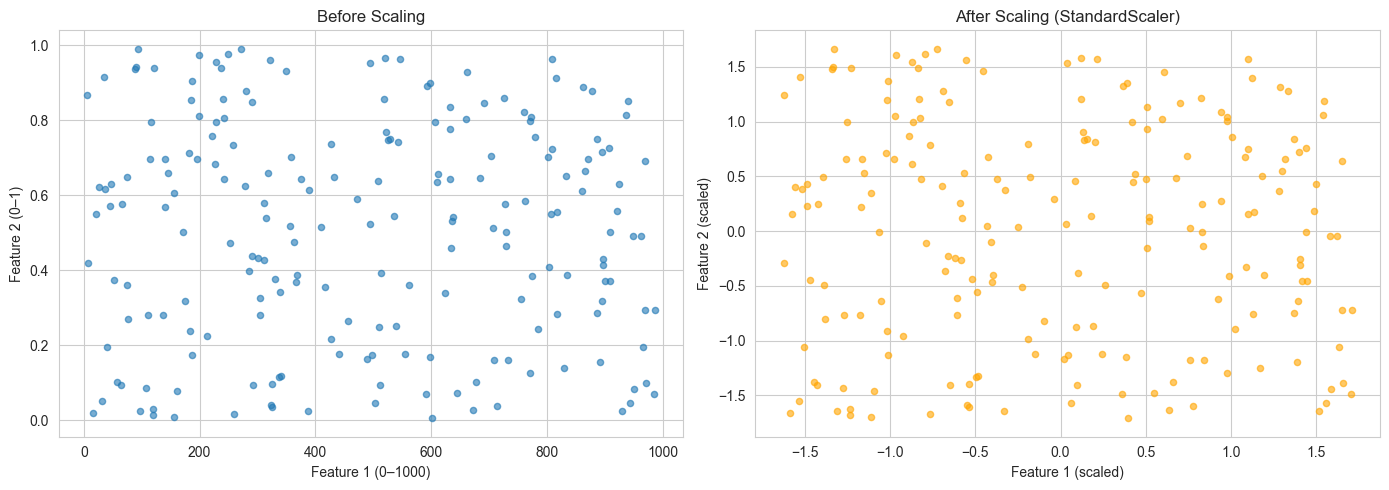

Rule of thumb: ALWAYS scale your features before clustering!


In [12]:
# Example: unscaled vs. scaled
from sklearn.preprocessing import StandardScaler

# Create data where Feature 1 ranges 0–1000 and Feature 2 ranges 0–1
np.random.seed(42)
X_unscaled = np.column_stack([
    np.random.uniform(0, 1000, 200),
    np.random.uniform(0, 1, 200)
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], s=20, alpha=0.6)
axes[0].set_title("Before Scaling")
axes[0].set_xlabel("Feature 1 (0–1000)")
axes[0].set_ylabel("Feature 2 (0–1)")

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], s=20, alpha=0.6, color="orange")
axes[1].set_title("After Scaling (StandardScaler)")
axes[1].set_xlabel("Feature 1 (scaled)")
axes[1].set_ylabel("Feature 2 (scaled)")

plt.tight_layout()
plt.show()

print("Rule of thumb: ALWAYS scale your features before clustering!")


## 7. Real-World Dataset — The Iris Dataset

Now let's apply what we've learned to a real dataset! The **Iris dataset** is a classic in machine learning. It contains measurements of 150 iris flowers from 3 species.

**Features (columns):**
- Sepal length (cm)
- Sepal width (cm)
- Petal length (cm)
- Petal width (cm)

We'll pretend we *don't know* the species and try to discover them using clustering.


In [13]:
# Load the Iris dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target  # true labels (we'll use these later to check our work)

print(f"Dataset shape: {X_iris.shape}")
print(f"\nFirst 5 rows:")
X_iris.head()


Dataset shape: (150, 4)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
# Quick look at the data distribution
X_iris.describe().round(2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### 📝 TODO #4
Before clustering, we should scale our features. Complete the code below.


In [ ]:
# TODO #4: Scale the iris features using StandardScaler
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(...)  # Replace ... with the correct variable

print(f"Mean after scaling (should be ~0): {X_iris_scaled.mean(axis=0).round(2)}")
print(f"Std after scaling  (should be ~1): {X_iris_scaled.std(axis=0).round(2)}")


Mean after scaling (should be ~0): [-0. -0. -0. -0.]
Std after scaling  (should be ~1): [1. 1. 1. 1.]


### Applying K-Means to Iris

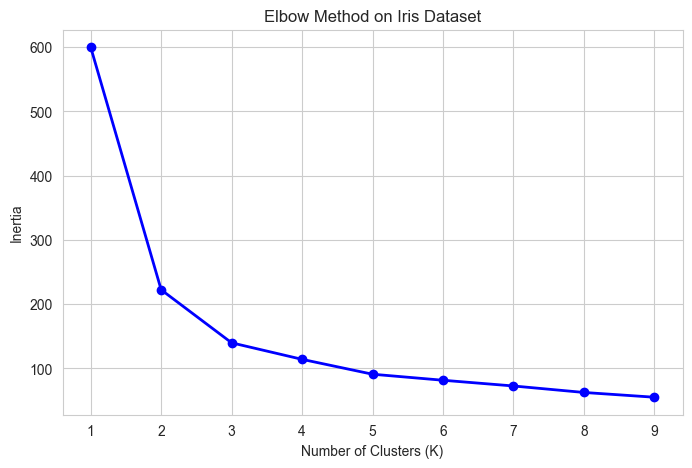

In [17]:
# Elbow method on Iris
inertias_iris = []
K_range_iris = range(1, 10)

for k in K_range_iris:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_iris_scaled)
    inertias_iris.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range_iris, inertias_iris, "bo-", linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method on Iris Dataset")
plt.xticks(list(K_range_iris))
plt.show()


<Figure size 1000x500 with 0 Axes>

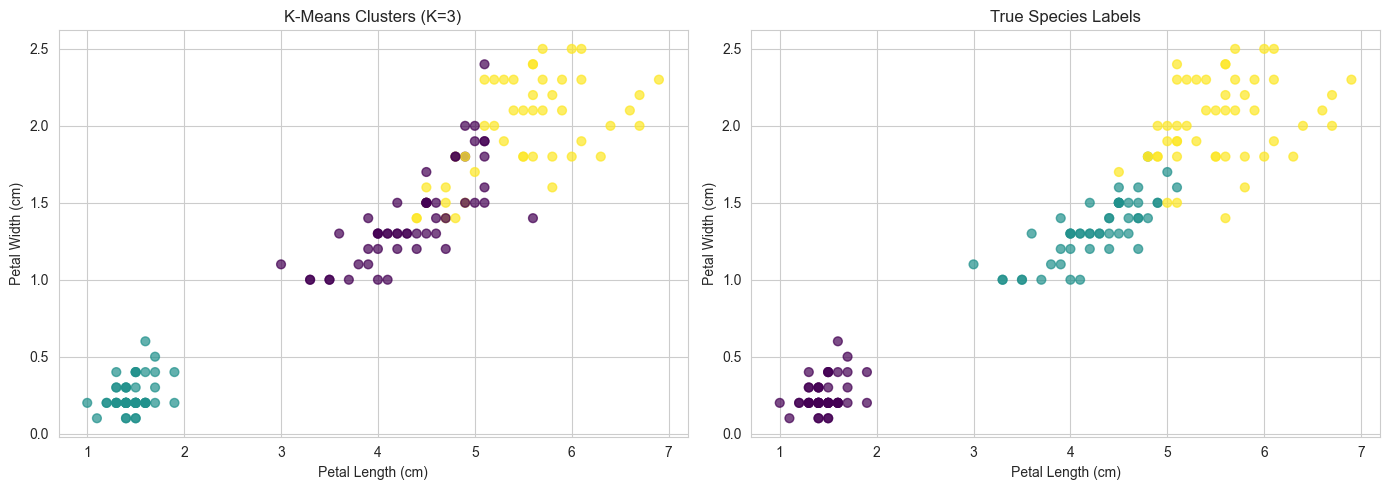

Silhouette Score: 0.460


In [18]:
# Cluster with K=3
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
iris_labels = kmeans_iris.fit_predict(X_iris_scaled)

# Visualize using the two most informative features: petal length & petal width
plt.figure(figsize=(10, 5))

# Left: Our clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_iris["petal length (cm)"], X_iris["petal width (cm)"],
                c=iris_labels, cmap="viridis", s=40, alpha=0.7)
axes[0].set_title("K-Means Clusters (K=3)")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")

# Right: True species labels (for comparison)
axes[1].scatter(X_iris["petal length (cm)"], X_iris["petal width (cm)"],
                c=y_iris, cmap="viridis", s=40, alpha=0.7)
axes[1].set_title("True Species Labels")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.tight_layout()
plt.show()

sil = silhouette_score(X_iris_scaled, iris_labels)
print(f"Silhouette Score: {sil:.3f}")


Notice how closely our unsupervised clusters match the true species labels! K-Means did a great job here.

---


## 8. Beyond K-Means — Other Clustering Algorithms

K-Means is powerful but has limitations. Let's look at two alternatives.

### 8.1 Hierarchical (Agglomerative) Clustering
- Builds a tree of clusters from the bottom up.
- No need to specify K in advance — you can cut the tree at any level.
- Good for understanding the *hierarchy* of relationships.

### 8.2 DBSCAN (Density-Based Clustering)
- Groups together points that are closely packed.
- Can find **arbitrarily shaped** clusters (not just round blobs).
- Automatically detects **outliers** (noise points).
- No need to specify K — but you set `eps` (neighborhood radius) and `min_samples`.


In [ ]:
# Let's create a dataset where K-Means struggles: two crescent moons
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
km_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km_moons.fit_predict(X_moons)
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, cmap="viridis", s=30)
axes[0].set_title("K-Means (struggles with shapes)")

# Hierarchical
hc = AgglomerativeClustering(n_clusters=2)
labels_hc = hc.fit_predict(X_moons)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_hc, cmap="viridis", s=30)
axes[1].set_title("Hierarchical Clustering")

# DBSCAN
db = DBSCAN(eps=0.2, min_samples=5)
labels_db = db.fit_predict(X_moons)
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, cmap="viridis", s=30)
axes[2].set_title("DBSCAN (handles shapes well!)")

plt.tight_layout()
plt.show()


### 📝 TODO #5
Look at the three plots above. Which algorithm handled the crescent-moon shapes the best?


In [ ]:
# TODO #5: Replace ... with the name of the best algorithm ("K-Means", "Hierarchical", or "DBSCAN")
best_algorithm = "..."
print(f"The best algorithm for crescent-shaped data is: {best_algorithm}")


## 9. Algorithm Comparison — When to Use What

| Feature | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| **Need to specify K?** | Yes | Yes (or cut dendrogram) | No |
| **Cluster shapes** | Round (convex) | Any | Any |
| **Handles outliers?** | No | No | Yes |
| **Speed on large data** | Fast | Slow | Medium |
| **Best for** | Well-separated round clusters | Small data, need hierarchy | Noisy data, irregular shapes |

---


## 10. Putting It All Together — A Complete Clustering Pipeline

Here's the general workflow for any clustering project:

1. **Load & explore** your data
2. **Clean** missing values, outliers
3. **Scale** features (StandardScaler)
4. **Choose K** (elbow + silhouette)
5. **Cluster** (K-Means, DBSCAN, etc.)
6. **Evaluate** (silhouette score, visualization)
7. **Interpret** the clusters


### 📝 TODO #6
Let's practice the full pipeline on the Iris dataset. Fill in the missing parts below.


In [ ]:
# TODO #6: Complete the pipeline

# Step 1: Load data (already done)
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Step 2: Check for missing values
print(f"Missing values per column:\n{X.isnull().sum()}")

# Step 3: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Choose K — run the elbow method
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Step 5: Cluster with your chosen K
best_k = ...  # TODO: Replace with your chosen K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = km_final.fit_predict(X_scaled)

# Step 6: Evaluate
score = silhouette_score(X_scaled, final_labels)
print(f"\nSilhouette Score with K={best_k}: {score:.3f}")

# Step 7: Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X["petal length (cm)"], X["petal width (cm)"],
            c=final_labels, cmap="viridis", s=40, alpha=0.7)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title(f"Final Clustering (K={best_k})")
plt.colorbar(label="Cluster")
plt.show()


## 11. Key Takeaways

Here's what you've learned in this notebook:

1. **Clustering** groups similar data points without labels (unsupervised).
2. **K-Means** is the go-to algorithm: fast, simple, but needs round clusters and a pre-set K.
3. **Always scale** your features before clustering.
4. Use the **Elbow Method** and **Silhouette Score** to pick the right K.
5. **DBSCAN** is better for irregular shapes and noisy data.
6. **Hierarchical clustering** gives you a tree you can cut at any level.
7. No single algorithm wins every time — the best choice depends on your data.

---


## 🏋️ Optional Exercises (Medium Difficulty)

These exercises use the **Wine dataset** from scikit-learn. It contains chemical analysis of wines grown in the same region in Italy, derived from three different cultivars.

> **Dataset info:** 178 samples, 13 features (alcohol, malic acid, ash, alkalinity, magnesium, phenols, flavanoids, etc.)


### Exercise 1: Explore and Prepare the Wine Dataset

Load the Wine dataset, explore it, and prepare it for clustering.


In [ ]:
from sklearn.datasets import load_wine

# Exercise 1a: Load the dataset and create a DataFrame
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Exercise 1b: Print the shape, first 5 rows, and basic statistics
# YOUR CODE HERE
# ...

# Exercise 1c: Scale the features using StandardScaler
# YOUR CODE HERE
# X_wine_scaled = ...


### Exercise 2: Find the Optimal K for the Wine Dataset

Use both the Elbow Method and Silhouette Score to determine the best number of clusters.

**Hint:** The wine dataset actually has 3 cultivars, but the "best" K for clustering may differ from the true number of classes.


In [ ]:
# Exercise 2a: Elbow Method — plot inertia for K = 1 to 10
# YOUR CODE HERE


# Exercise 2b: Silhouette Score — plot scores for K = 2 to 10
# YOUR CODE HERE


# Exercise 2c: What K did you choose and why?
# chosen_k = ...


### Exercise 3: Compare All Three Algorithms on Wine Data

Apply K-Means, Hierarchical Clustering, and DBSCAN to the scaled wine data. Calculate the silhouette score for each.

**Hint for DBSCAN:** Since the data has 13 features, you may need to experiment with `eps` values (try 2.0–5.0) and `min_samples` (try 3–10).


In [ ]:
# Exercise 3a: K-Means
# YOUR CODE HERE
# km_wine = KMeans(...)
# km_labels = ...
# km_sil = ...

# Exercise 3b: Hierarchical Clustering
# YOUR CODE HERE
# hc_wine = AgglomerativeClustering(...)
# hc_labels = ...
# hc_sil = ...

# Exercise 3c: DBSCAN (experiment with eps and min_samples)
# YOUR CODE HERE
# db_wine = DBSCAN(...)
# db_labels = ...
# If DBSCAN found more than 1 cluster, compute silhouette score

# Exercise 3d: Print a comparison table of silhouette scores
# print(f"K-Means Silhouette:       {km_sil:.3f}")
# print(f"Hierarchical Silhouette:  {hc_sil:.3f}")
# print(f"DBSCAN Silhouette:        {db_sil:.3f}")


### Exercise 4: Visualize with PCA (Dimensionality Reduction)

The Wine dataset has 13 features, so we can't easily plot it. **PCA** (Principal Component Analysis) reduces the data to 2 dimensions while keeping as much information as possible.

Use PCA to reduce the wine data to 2D, then plot the clusters from each algorithm side by side.


In [ ]:
from sklearn.decomposition import PCA

# Exercise 4a: Reduce to 2D with PCA
pca = PCA(n_components=2)
X_wine_2d = pca.fit_transform(X_wine_scaled)  # make sure you've scaled first!

print(f"Explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.1%}")

# Exercise 4b: Create a 1x3 subplot showing K-Means, Hierarchical, and DBSCAN results
# on the PCA-reduced data. Add a 4th subplot showing the true wine labels for comparison.
# YOUR CODE HERE
# fig, axes = plt.subplots(1, 4, figsize=(22, 5))
# ...


### Exercise 5: Cluster Profiling

After clustering, it's useful to understand *what makes each cluster different*. Create a summary showing the mean value of each feature per cluster.

**Bonus:** Identify the top 3 features that differ the most between clusters.


In [ ]:
# Exercise 5a: Add the cluster labels to the original (unscaled) DataFrame
# and compute the mean of each feature per cluster
# YOUR CODE HERE
# X_wine["cluster"] = km_labels  # using K-Means labels
# cluster_means = X_wine.groupby("cluster").mean()
# print(cluster_means.round(2))

# Exercise 5b (Bonus): Find the top 3 features with the largest
# difference between clusters (hint: look at the standard deviation
# of the cluster means for each feature)
# YOUR CODE HERE


---

## 🎉 Congratulations!

You've completed this introduction to clustering! Here's what to explore next:

- **More algorithms:** Gaussian Mixture Models (GMMs), Spectral Clustering
- **Dimensionality reduction:** t-SNE, UMAP for better visualization
- **Real projects:** Try clustering on Kaggle datasets
- **scikit-learn docs:** [https://scikit-learn.org/stable/modules/clustering.html](https://scikit-learn.org/stable/modules/clustering.html)

Happy clustering! 🚀
